# Startup Success Prediction - Data Analysis and EDA

This notebook demonstrates:
1. Data loading and initial exploration
2. Exploratory Data Analysis (EDA)
3. Data quality assessment
4. Feature distributions and correlations
5. Class imbalance analysis

In [6]:
# Import necessary libraries
import sys
import os
sys.path.append('../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 1. Data Loading

We load preprocessed data that combines YC and Crunchbase information.

In [7]:
from app.data_config import load_real_data_fast

# Load merged and preprocessed data
df = load_real_data_fast()

print(f"Dataset shape: {df.shape}")
print(f"\nColumns ({len(df.columns)}): {list(df.columns)}")
print("\n" + "="*80)

Loading YC dataset...
Error: [Errno 2] No such file or directory: 'data/raw/yc_companies.csv', falling back to sample data
Dataset shape: (1000, 8)

Columns (8): ['company_name', 'company_age', 'total_funding', 'funding_rounds', 'team_size', 'industry', 'region', 'target']



### 1.1 Dataset Overview

In [8]:
print("Dataset - First 5 rows:")
display(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
}).sort_values('Percentage', ascending=False)
display(missing_df[missing_df['Missing Count'] > 0])

Dataset - First 5 rows:


,company_name,company_age,total_funding,funding_rounds,team_size,industry,region,target
0,Company_0,7,116593.377581,9,19,Finance,New York,1
1,Company_1,15,1551.413869,5,18,E-commerce,Seattle,0
2,Company_2,11,10680.960656,8,16,Tech,Boston,1
3,Company_3,8,19164.604752,2,8,Finance,Other,1
4,Company_4,7,58141.326712,6,33,Healthcare,Boston,1



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   company_name    1000 non-null   object 
 1   company_age     1000 non-null   int64  
 2   total_funding   1000 non-null   float64
 3   funding_rounds  1000 non-null   int64  
 4   team_size       1000 non-null   int64  
 5   industry        1000 non-null   object 
 6   region          1000 non-null   object 
 7   target          1000 non-null   int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 62.6+ KB
None

Missing values:


,Missing Count,Percentage


## 2. Target Variable Analysis

Our target variable is **company success**:
- **Success (1)**: Active, Acquired, Public
- **Failure (0)**: Inactive, Closed, Dead

In [9]:
# Check if status column exists
if 'status' in df.columns:
    print("Status Distribution:")
    print(df['status'].value_counts())
    print("\n" + "="*40)

print("\nTarget Distribution:")
target_counts = df['target'].value_counts()
print(target_counts)
print("\nTarget Proportions:")
print(df['target'].value_counts(normalize=True).mul(100).round(2))


Target Distribution:
target
1    667
0    333
Name: count, dtype: int64

Target Proportions:
target
1    66.7
0    33.3
Name: proportion, dtype: float64


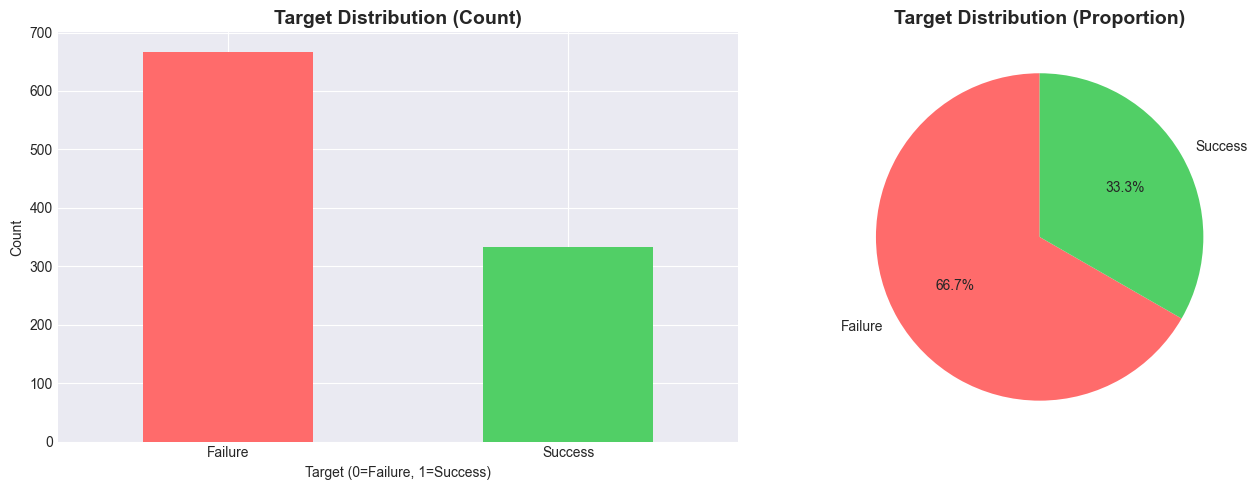


⚠️ Class Imbalance Ratio: 2.00:1


In [10]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
target_counts.plot(kind='bar', ax=axes[0], color=['#ff6b6b', '#51cf66'])
axes[0].set_title('Target Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Target (0=Failure, 1=Success)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Failure', 'Success'], rotation=0)

# Pie chart
target_props = df['target'].value_counts(normalize=True)
axes[1].pie(target_props.values, labels=['Failure', 'Success'], autopct='%1.1f%%',
           colors=['#ff6b6b', '#51cf66'], startangle=90)
axes[1].set_title('Target Distribution (Proportion)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n⚠️ Class Imbalance Ratio: {target_counts.max() / target_counts.min():.2f}:1")

## 3. Feature Analysis

### 3.1 Numerical Features

In [11]:
# Select numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [col for col in numerical_cols if col != 'target']

print(f"Numerical features ({len(numerical_cols)}): {numerical_cols}")

# Summary statistics
print("\nNumerical Features - Summary Statistics:")
display(df[numerical_cols].describe())

Numerical features (4): ['company_age', 'total_funding', 'funding_rounds', 'team_size']

Numerical Features - Summary Statistics:


,company_age,total_funding,funding_rounds,team_size
count,1000.000000,1.000000e+03,1000.000000,1000.000000
mean,9.746000,1.351820e+05,5.002000,25.160000
std,5.651497,4.962356e+05,2.606298,14.063007
min,1.000000,2.087145e+01,1.000000,1.000000
25%,5.000000,5.553757e+03,3.000000,13.000000
50%,9.000000,2.293384e+04,5.000000,25.000000
75%,15.000000,7.688323e+04,7.000000,37.250000
max,19.000000,8.285526e+06,9.000000,49.000000


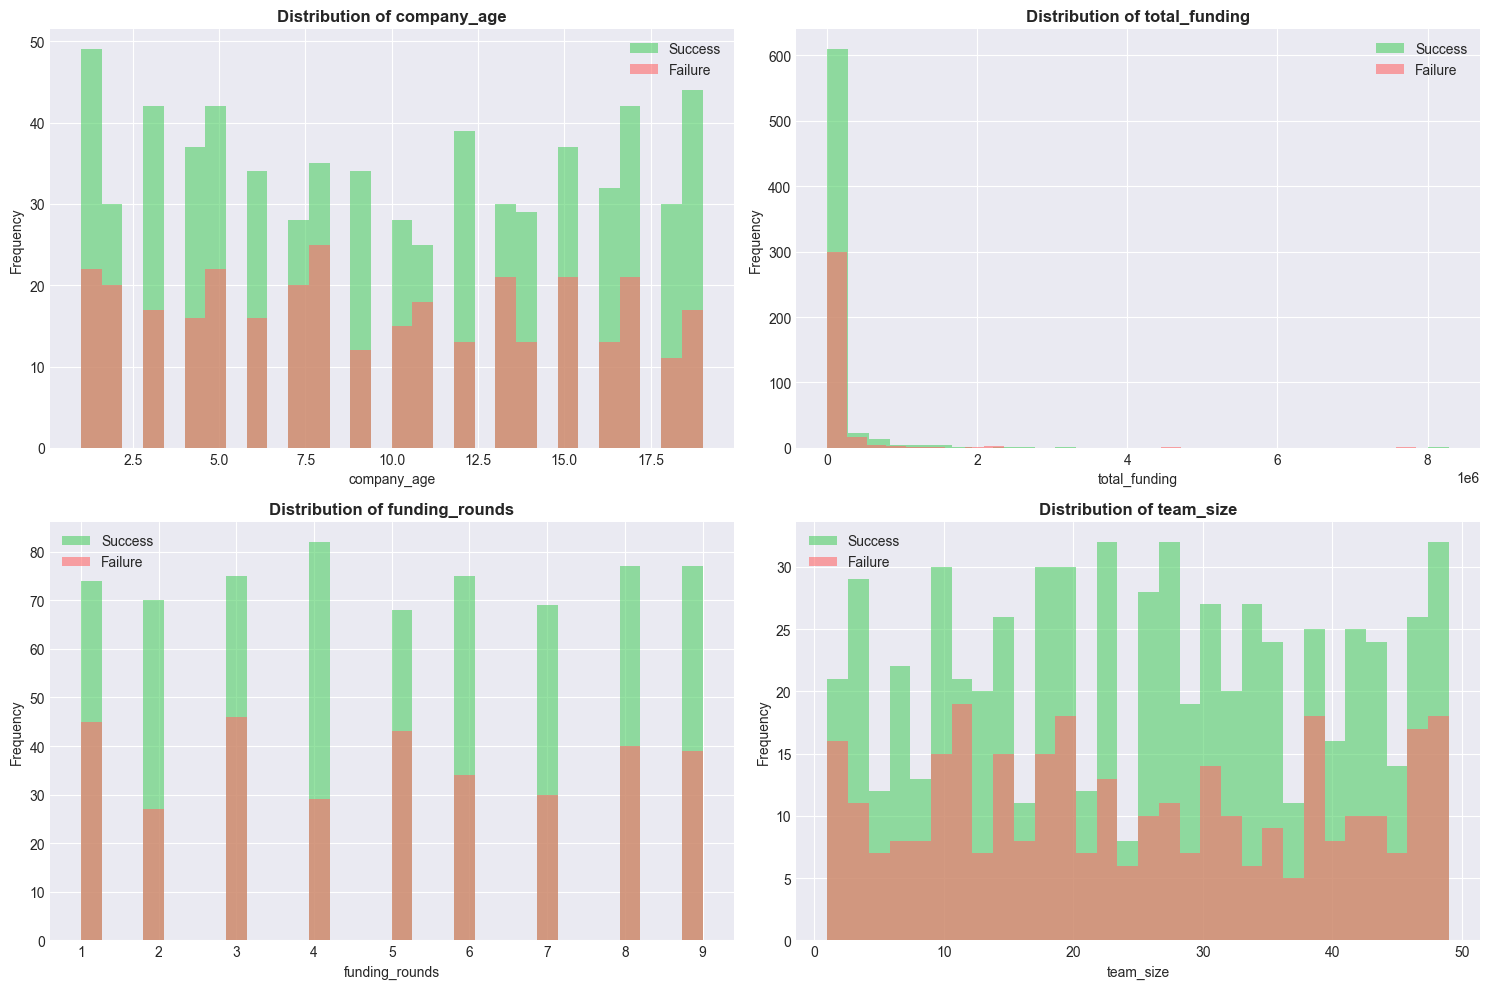

In [12]:
# Distribution plots for key numerical features
key_features = ['company_age', 'total_funding', 'funding_rounds', 'team_size']
key_features = [f for f in key_features if f in df.columns]

if len(key_features) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.ravel()
    
    for idx, col in enumerate(key_features):
        if idx < len(axes):
            # Plot for success vs failure
            df[df['target']==1][col].hist(ax=axes[idx], bins=30, alpha=0.6, 
                                          label='Success', color='#51cf66')
            df[df['target']==0][col].hist(ax=axes[idx], bins=30, alpha=0.6, 
                                          label='Failure', color='#ff6b6b')
            axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel('Frequency')
            axes[idx].legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("No key features found in dataset")

### 3.2 Categorical Features

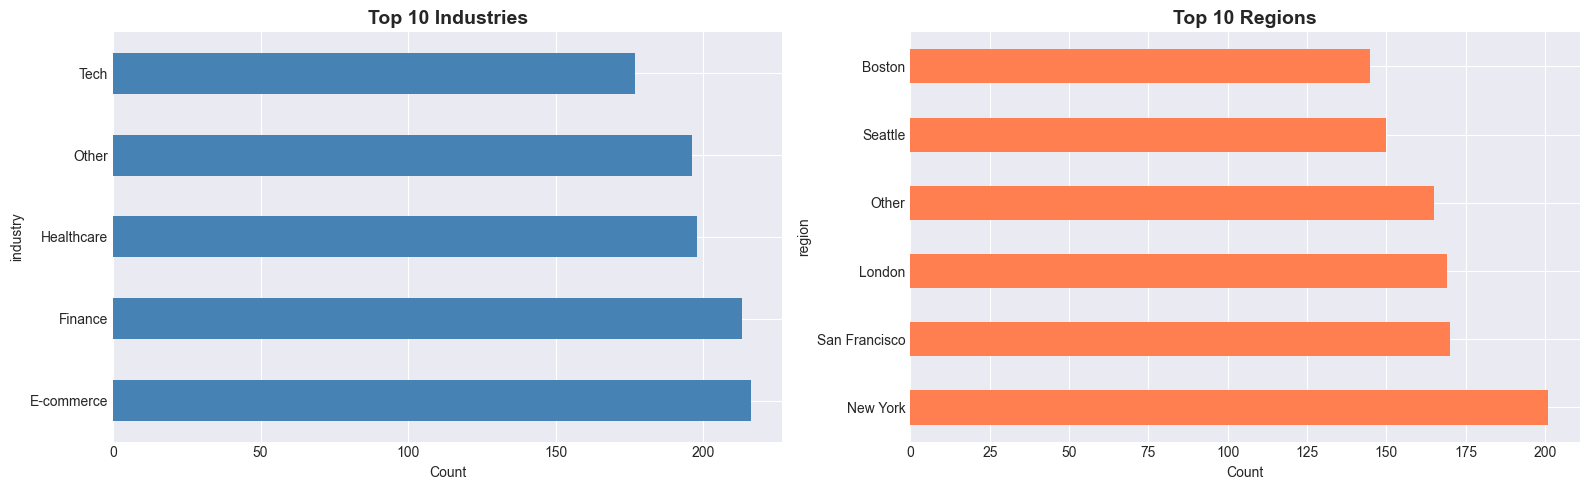

In [13]:
# Visualize top categories for industry and region
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Industry
if 'industry' in df.columns:
    top_industries = df['industry'].value_counts().head(10)
    top_industries.plot(kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_title('Top 10 Industries', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Count')
else:
    axes[0].text(0.5, 0.5, 'Industry column not found', ha='center', va='center')

# Region
if 'region' in df.columns:
    top_regions = df['region'].value_counts().head(10)
    top_regions.plot(kind='barh', ax=axes[1], color='coral')
    axes[1].set_title('Top 10 Regions', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Count')
else:
    axes[1].text(0.5, 0.5, 'Region column not found', ha='center', va='center')

plt.tight_layout()
plt.show()

## 4. Correlation Analysis

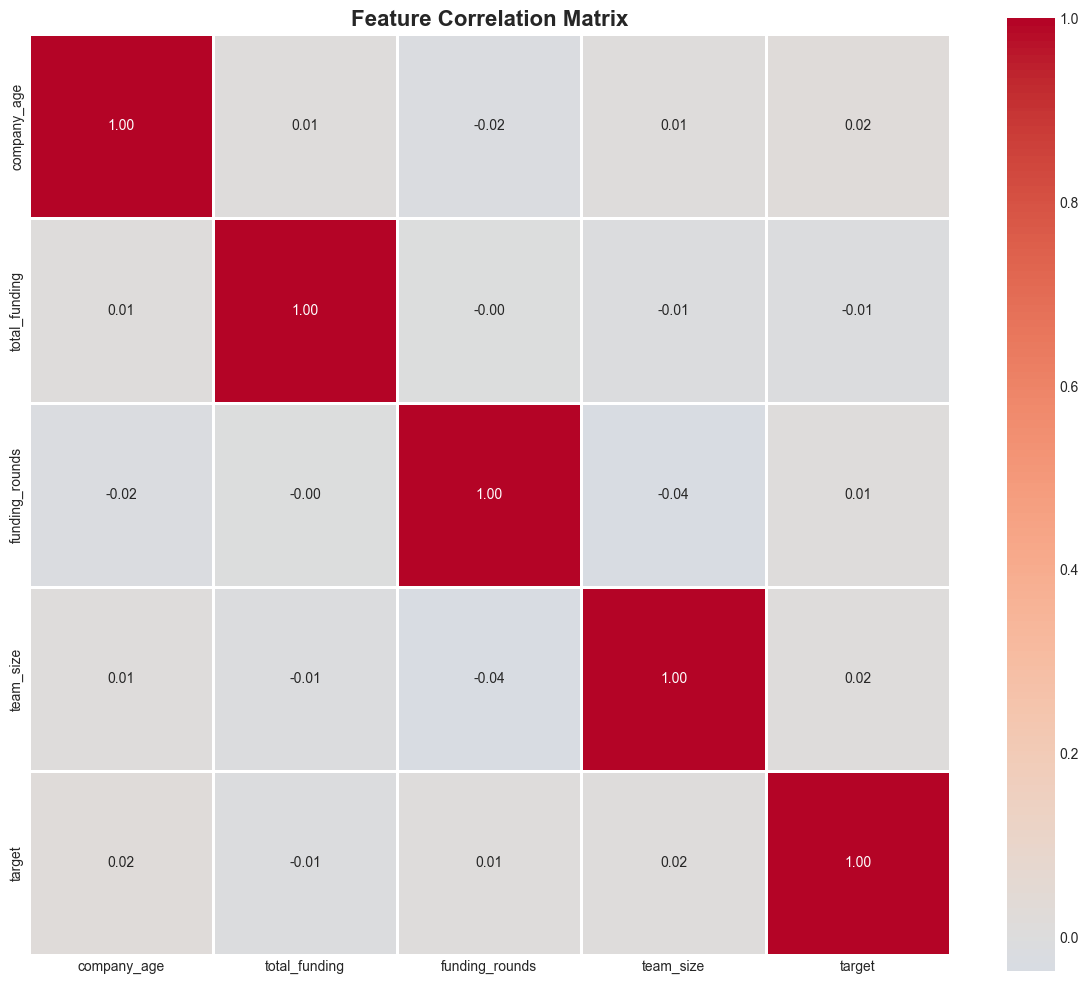


Features most correlated with target:
company_age       0.020441
team_size         0.015893
funding_rounds    0.010317
total_funding    -0.010079
Name: target, dtype: float64


In [14]:
# Correlation matrix for numerical features
corr_features = numerical_cols + ['target']
corr_features = [f for f in corr_features if f in df.columns]

if len(corr_features) > 1:
    correlation_matrix = df[corr_features].corr()
    
    # Visualize correlation matrix
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1)
    plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Show features most correlated with target
    if 'target' in correlation_matrix.columns:
        print("\nFeatures most correlated with target:")
        target_corr = correlation_matrix['target'].drop('target').sort_values(ascending=False)
        print(target_corr)
else:
    print("Not enough features for correlation analysis")

## 5. Key Insights Summary

In [15]:
print("="*80)
print("KEY INSIGHTS FROM EDA")
print("="*80)

print(f"\n1. Dataset Size: {len(df):,} companies")

target_dist = df['target'].value_counts(normalize=True) * 100
print(f"\n2. Class Distribution:")
print(f"   - Success: {target_dist[1]:.1f}%")
print(f"   - Failure: {target_dist[0]:.1f}%")
print(f"   - Imbalance Ratio: {df['target'].value_counts().max() / df['target'].value_counts().min():.2f}:1")

print(f"\n3. Number of Features: {len(df.columns) - 1} (excluding target)")
print(f"   - Numerical: {len(numerical_cols)}")

print("\n" + "="*80)
print("✅ EDA Complete - Ready for modeling")
print("="*80)

KEY INSIGHTS FROM EDA

1. Dataset Size: 1,000 companies

2. Class Distribution:
   - Success: 66.7%
   - Failure: 33.3%
   - Imbalance Ratio: 2.00:1

3. Number of Features: 7 (excluding target)
   - Numerical: 4

✅ EDA Complete - Ready for modeling
